In [177]:
from scr.SPMe import Solid_Phase
from scr.pinn import FFNN
from scr.utils import load_params

import ipywidgets as widgets
import matplotlib.pyplot as plt

import pybamm
import torch

In [2]:
parameters = load_params()

model = FFNN(2, 1)
PINN_pos = Solid_Phase(model, parameters, electrode="pos")
PINN_pos.load_model("models/positive_imp.pt")
PINN_neg = Solid_Phase(model, parameters, electrode="neg")
PINN_neg.load_model("models/negative.pt")

param = pybamm.ParameterValues("Chen2020")
PBM_model = pybamm.lithium_ion.SPM()
experiment = pybamm.Experiment(["Discharge at 1C for 10000 seconds or until 2.5 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1)

x = solution["x [m]"].entries[:, 0]

c_s_n = solution["Negative particle concentration"]
c_s_p = solution["Positive particle concentration"]
r_n = solution["r_n [m]"].entries[:, 0, 0]
r_p = solution["r_p [m]"].entries[:, 0, 0]

In [3]:
def plot_concentrations(t):

    bc_sample_r = torch.linspace(0., 1., 1000)
    bc_sample_t = torch.ones_like(bc_sample_r)
    bc_sample = torch.stack([bc_sample_t, bc_sample_r]).t()

    c_pinn_p = PINN_pos(bc_sample)
    c_pinn_n = PINN_neg(bc_sample)

    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    (plot_c_n,) = ax1.plot(
        r_n, c_s_n(r=r_n, t=t * 3600, x=x[0])
    )  # can evaluate at arbitrary x (single representative particle)
    (plot_c_p,) = ax2.plot(
        r_p, c_s_p(r=r_p, t=t * 3600, x=x[-1])
    )  # can evaluate at arbitrary x (single representative particle)

    (plot_c_n,) = ax1.plot(
        bc_sample_r.detach().numpy(), c_pinn_p.detach().numpy()
    )  # can evaluate at arbitrary x (single representative particle)
    (plot_c_p,) = ax2.plot(
        bc_sample_r.detach().numpy(), c_pinn_n.detach().numpy()
    )  # can evaluate at arbitrary x (single representative particle)
    ax1.set_ylabel("Negative particle concentration")
    ax2.set_ylabel("Positive particle concentration")
    ax1.set_xlabel(r"$r_n$ [m]")
    ax2.set_xlabel(r"$r_p$ [m]")
    ax1.set_ylim(0, 1)
    ax2.set_ylim(0, 1)
    plt.show()

widgets.interact(
    plot_concentrations, t=widgets.FloatSlider(min=0, max=1, step=10, value=0)
)

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=10.0), Output()), _dom_classes=('w…

<function __main__.plot_concentrations(t)>

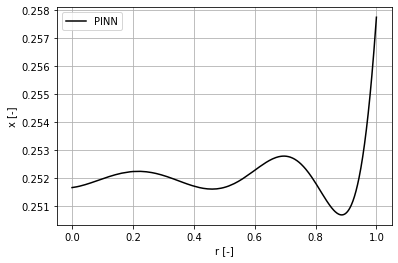

In [4]:

bcs_sample_r = torch.linspace(0., 1., 1000)
bcs_sample_t = torch.zeros_like(bcs_sample_r)
bcs_sample = torch.stack([bcs_sample_t, bcs_sample_r]).t()
c_bcs = PINN_pos(bcs_sample)

plt.figure()
plt.grid("on")
plt.plot(bcs_sample_r.detach().numpy(), c_bcs.detach().numpy(), "k", label="PINN")
#plt.plot(t, pos_SPM_r1, "r", label="Pybamm")
plt.legend()
plt.xlabel("r [-]")
plt.ylabel("x [-]")
plt.show()

## Residual plots

In [5]:
import numpy as np

num = 1000.

t_test = (torch.arange(0, num, dtype=torch.float, requires_grad=True)/num)[::10]
r_rand = (torch.arange(0, num, dtype=torch.float, requires_grad=True)/num)[::10]

t_new, r_new = torch.meshgrid(t_test, r_rand)
pos = np.zeros_like(t_new.detach().numpy())
neg = np.zeros_like(t_new.detach().numpy())

pos_dcdt = np.zeros_like(t_new.detach().numpy())
neg_dcdt = np.zeros_like(t_new.detach().numpy())
pos_dcdr = np.zeros_like(t_new.detach().numpy())
neg_dcdr = np.zeros_like(t_new.detach().numpy())

for i, (t, r) in enumerate(zip(t_new, r_new)):

  residuals = PINN_pos.compute_residuals(torch.stack((t, r)).t())
  pos[i, :] = np.abs(residuals.detach().numpy())
  gradients = PINN_pos.compute_gradients(torch.stack((t, r)).t())
  pos_dcdt[i, :] = np.abs(gradients[:,0].detach().numpy())
  pos_dcdr[i, :] = np.abs(gradients[:,1].detach().numpy())
  
  residuals = PINN_neg.compute_residuals(torch.stack((t, r)).t())
  neg[i, :] = np.abs(residuals.detach().numpy())
  gradients = PINN_neg.compute_gradients(torch.stack((t, r)).t())
  neg_dcdt[i, :] = np.abs(gradients[:,0].detach().numpy())
  neg_dcdr[i, :] = np.abs(gradients[:,1].detach().numpy())

In [6]:
def plot_area(points, style, cmap_label):
    plt.subplots(figsize=(7,3), tight_layout=True)
    plot = plt.pcolormesh(t_new.detach().numpy(), r_new.detach().numpy(), points, cmap=style, shading='gouraud')
    cbar = plt.colorbar(plot)
    plt.contour(t_new.detach().numpy(), r_new.detach().numpy(), points, 10, colors='gray')
    plt.ylabel('$r$')
    plt.xlabel('$t$ [h]')
    cbar.set_label(cmap_label)
    # plt.savefig('/content/drive/MyDrive/Datos/con_PINN_pos.png')
    plt.show()

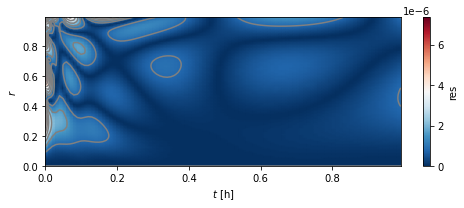

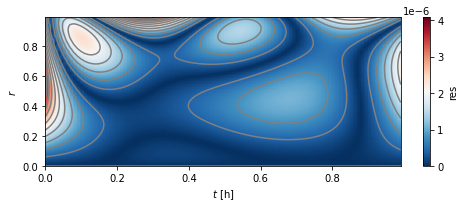

In [7]:
plot_area(pos, 'RdBu_r', 'res')
plot_area(neg, 'RdBu_r', 'res')

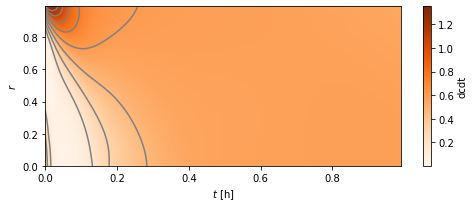

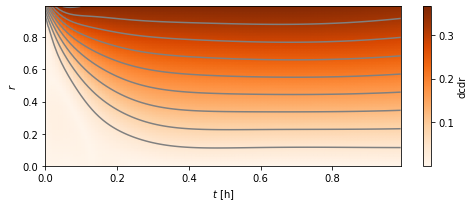

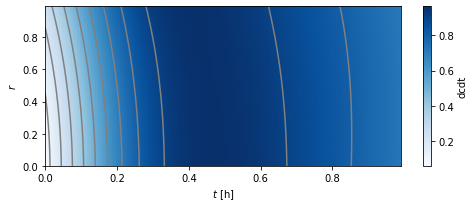

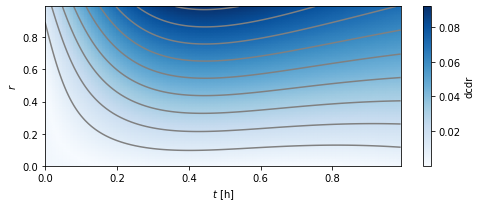

In [8]:
plot_area(pos_dcdt, 'Oranges', 'dcdt')
plot_area(pos_dcdr, 'Oranges', 'dcdr')
plot_area(neg_dcdt, 'Blues', 'dcdt')
plot_area(neg_dcdr, 'Blues', 'dcdr')

## Current

In [155]:
parameters = load_params()

model = FFNN(3, 1)
PINN_pos = Solid_Phase(model, parameters, electrode="pos")
PINN_pos.load_model("models/positive_current.pt")

PINN_neg = Solid_Phase(model, parameters, electrode="neg")
PINN_neg.load_model("models/negative_current.pt")

param = pybamm.ParameterValues("Chen2020")
PBM_model = pybamm.lithium_ion.SPM()


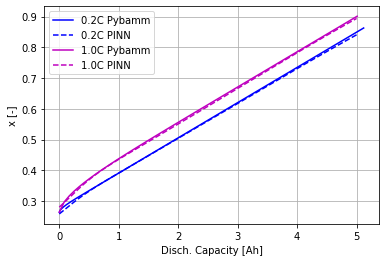

In [184]:
plt.figure()
plt.grid("on")

for k, c in zip([0.2, 0.9, 1.5], ["b", "m", "k"]):
    
    experiment = pybamm.Experiment(["Discharge at "+ str(k) +"C for 100000 seconds or until 2.5 V"])
    sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
    solution = sim.solve(initial_soc=1)
    
    x = solution["x [m]"].entries[:, 0]
    
    t = solution["Time [s]"].entries
    
    c_s_p = solution["Positive particle concentration"]
    r_p = solution["r_p [m]"].entries[:, 0, 0]
    
    pos_SPM_r1 = c_s_p(r=r_p[-1], t=t, x=x[-1])
    
    plt.plot(t / 3600. * k * parameters["I_typ"], pos_SPM_r1, c+"-",label=str(k)+"C Pybamm")
    
    bcs_sample_t = torch.linspace(0., 1., 1000)
    bcs_sample_r = torch.ones_like(bcs_sample_t)
    bcs_sample_I = torch.ones_like(bcs_sample_t) * k
    bcs_sample = torch.stack([bcs_sample_t, bcs_sample_r, bcs_sample_I]).t()
    c_bcs = PINN_pos(bcs_sample)
    
    plt.plot(bcs_sample_t.detach().numpy() * parameters["I_typ"], c_bcs.detach().numpy(), c+"--", label=str(k)+"C PINN")
    
plt.legend()
plt.xlabel("Disch. Capacity [Ah]")
plt.ylabel("x [-]")
plt.show()

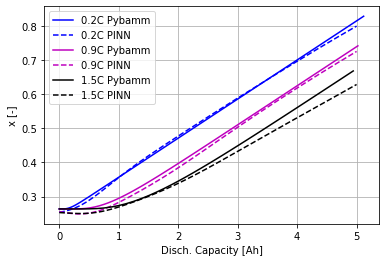

In [157]:
plt.figure()
plt.grid("on")

for k, c in zip([0.2, 0.9, 1.5], ["b", "m", "k"]):
    
    experiment = pybamm.Experiment(["Discharge at "+ str(k) +"C for 100000 seconds or until 2.5 V"])
    sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
    solution = sim.solve(initial_soc=1)
    
    x = solution["x [m]"].entries[:, 0]
    
    t = solution["Time [s]"].entries
    
    c_s_p = solution["Positive particle concentration"]
    r_p = solution["r_p [m]"].entries[:, 0, 0]
    
    pos_SPM_r1 = c_s_p(r=r_p[0], t=t, x=x[-1])
    
    plt.plot(t / 3600. * k * parameters["I_typ"], pos_SPM_r1, c+"-",label=str(k)+"C Pybamm")
    
    bcs_sample_t = torch.linspace(0., 1., 1000)
    bcs_sample_r = torch.zeros_like(bcs_sample_t)
    bcs_sample_I = torch.ones_like(bcs_sample_t) * k
    bcs_sample = torch.stack([bcs_sample_t, bcs_sample_r, bcs_sample_I]).t()
    c_bcs = PINN_pos(bcs_sample)
    
    plt.plot(bcs_sample_t.detach().numpy()* parameters["I_typ"], c_bcs.detach().numpy(), c+"--", label=str(k)+"C PINN")
    
plt.legend()
plt.xlabel("Disch. Capacity [Ah]")
plt.ylabel("x [-]")
plt.show()

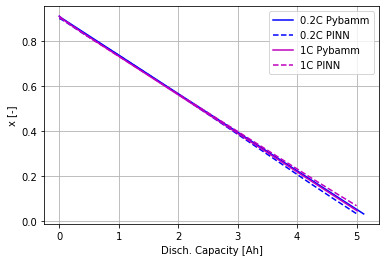

In [182]:
plt.figure()
plt.grid("on")

for k, c in zip([0.2, 0.9, 1.5], ["b", "m", "k"]):
    
    experiment = pybamm.Experiment(["Discharge at "+ str(k) +"C for 100000 seconds or until 2.5 V"])
    sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
    solution = sim.solve(initial_soc=1)
    
    x = solution["x [m]"].entries[:, 0]
    
    t = solution["Time [s]"].entries
    
    c_s_n = solution["Negative particle concentration"]
    r_n = solution["r_p [m]"].entries[:, 0, 0]
    
    neg_SPM_r1 = c_s_n(r=r_n[-1], t=t, x=x[0])
    
    plt.plot(t / 3600. * k * parameters["I_typ"], neg_SPM_r1, c+"-",label=str(k)+"C Pybamm")
    
    bcs_sample_t = torch.linspace(0., 1., 1000)
    bcs_sample_r = torch.ones_like(bcs_sample_t)
    bcs_sample_I = torch.ones_like(bcs_sample_t) * k
    bcs_sample = torch.stack([bcs_sample_t, bcs_sample_r, bcs_sample_I]).t()
    c_bcs = PINN_neg(bcs_sample)
    
    plt.plot(bcs_sample_t.detach().numpy()* parameters["I_typ"], c_bcs.detach().numpy(), c+"--", label=str(k)+"C PINN")
    
plt.legend()
plt.xlabel("Disch. Capacity [Ah]")
plt.ylabel("x [-]")
plt.show()

## Voltage estimation

In [178]:
parameters = load_params()

model = FFNN(3, 1)
PINN_pos = Solid_Phase(model, parameters, electrode="pos")
PINN_pos.load_model("models/positive_current.pt")

PINN_neg = Solid_Phase(model, parameters, electrode="neg")
PINN_neg.load_model("models/negative_current.pt")

param = pybamm.ParameterValues("Chen2020")
PBM_model = pybamm.lithium_ion.SPM()

In [179]:
def v_comp(I, c_p, c_n):
    OCV = parameters["E_p"](c_p) - parameters["E_n"](c_n)
    
    RT_F = parameters["R"]*parameters["T"]/ parameters["F"]
    j_p = - I / (parameters["L_p"] * parameters["as_p"] * parameters["A"])
    j_n = I / (parameters["L_n"] * parameters["as_n"] * parameters["A"])
    
    m_ref_p = 3.42e-6
    m_ref_n = 6.48e-7
    
    j0_p = m_ref_p * 31.62 * parameters["c_p_max"] * torch.sqrt(c_p) * torch.sqrt(1 - c_p)
    j0_n = m_ref_n * 31.62 * parameters["c_n_max"] * torch.sqrt(c_n) * torch.sqrt(1 - c_n)
    
    eta_p = 2 * RT_F * torch.arcsinh(j_p / (2 * j0_p))
    eta_n = 2 * RT_F * torch.arcsinh(j_n / (2 * j0_n))

    return OCV + eta_p - eta_n

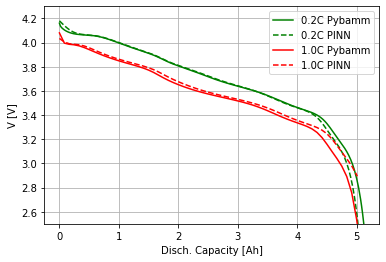

In [181]:
plt.figure()
plt.grid("on")

for k, c in zip([0.2, 0.9], ["g", "r"]):
    
    experiment = pybamm.Experiment(["Discharge at "+ str(k) +"C for 100000 seconds or until 2.5 V"])
    sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
    solution = sim.solve(initial_soc=1)
    
    t = solution["Time [s]"].entries
    
    V = solution["Terminal voltage [V]"].entries
    OCP_n = solution["Negative electrode open circuit potential [V]"].entries[0,:]
    OCP_p = solution["Positive electrode open circuit potential [V]"].entries[0,:]
    # V = OCP_p-OCP_n
    
    plt.plot(t / 3600. * k * parameters["I_typ"], V, c+"-",label=str(k)+"C Pybamm")
    
    bcs_sample_t = torch.Tensor(t / 3600. * k)
    bcs_sample_r = torch.ones_like(bcs_sample_t)
    bcs_sample_I = torch.ones_like(bcs_sample_t) * k
    bcs_sample = torch.stack([bcs_sample_t, bcs_sample_r, bcs_sample_I]).t()
    c_p = PINN_pos(bcs_sample)
    c_n = PINN_neg(bcs_sample)
    
    V_pinn = v_comp(parameters["I_typ"]*k, c_p, c_n)
    
    plt.plot(bcs_sample_t.detach().numpy()* parameters["I_typ"], V_pinn.detach().numpy(), c+"--", label=str(k)+"C PINN")
    
plt.ylim([2.5, 4.3])
plt.legend()
plt.xlabel("Disch. Capacity [Ah]")
plt.ylabel("V [V]")
plt.show()

In [176]:
param = pybamm.ParameterValues("Chen2020")
PBM_model = pybamm.lithium_ion.SPMe()
experiment = pybamm.Experiment(["Discharge at 0.5C for 100000 seconds or until 2.5 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1)

ce = solution["Electrolyte concentration [mol.m-3]"]

x = solution["x [m]"].entriesx[:,0]

ce(t=1, x=x)
param["Positive electrode thickness [m]"] + param["Negative electrode thickness [m]"] + param["Separator thickness [m]"]

[2.1300e-06 6.3900e-06 1.0650e-05 1.4910e-05 1.9170e-05 2.3430e-05
 2.7690e-05 3.1950e-05 3.6210e-05 4.0470e-05 4.4730e-05 4.8990e-05
 5.3250e-05 5.7510e-05 6.1770e-05 6.6030e-05 7.0290e-05 7.4550e-05
 7.8810e-05 8.3070e-05 8.5500e-05 8.6100e-05 8.6700e-05 8.7300e-05
 8.7900e-05 8.8500e-05 8.9100e-05 8.9700e-05 9.0300e-05 9.0900e-05
 9.1500e-05 9.2100e-05 9.2700e-05 9.3300e-05 9.3900e-05 9.4500e-05
 9.5100e-05 9.5700e-05 9.6300e-05 9.6900e-05 9.9090e-05 1.0287e-04
 1.0665e-04 1.1043e-04 1.1421e-04 1.1799e-04 1.2177e-04 1.2555e-04
 1.2933e-04 1.3311e-04 1.3689e-04 1.4067e-04 1.4445e-04 1.4823e-04
 1.5201e-04 1.5579e-04 1.5957e-04 1.6335e-04 1.6713e-04 1.7091e-04]


0.0001728